# **Used Car Price Prediction**

In [18]:
# General Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import difflib

# Model Training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from preprocessing import load_and_merge, clean_data, remove_outlier, feature_engineering

## Exploratory Data Analysis

 EDA 

Deskripsi Harga:
count    8.190000e+02
mean     2.033015e+08
std      1.582847e+08
min      6.250000e+07
25%      1.322500e+08
50%      1.780000e+08
75%      2.160000e+08
max      2.400000e+09
Name: price (Rp), dtype: float64

Top Brand:
brand
toyota        239
honda         186
daihatsu      108
mitsubishi     78
suzuki         70
Name: count, dtype: int64


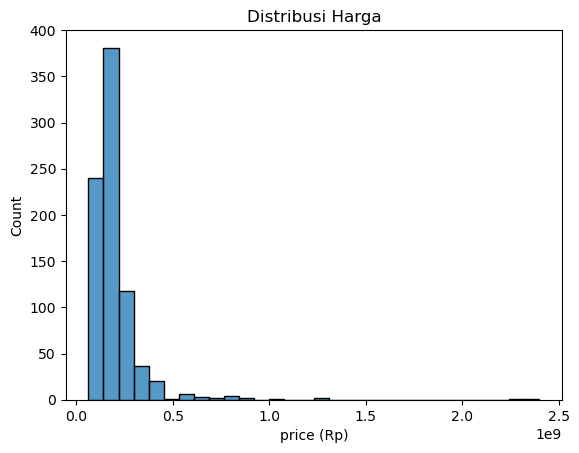

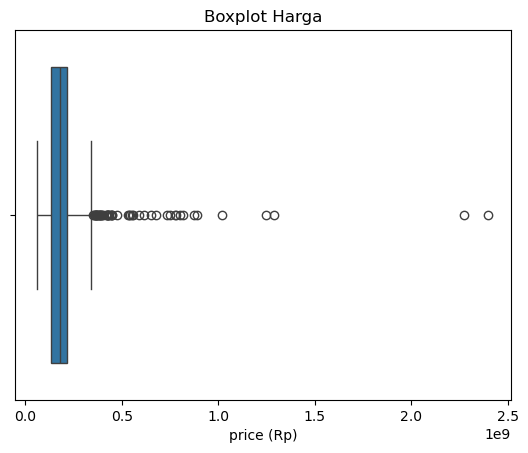

In [19]:
def run_eda(df):
    print(" EDA ")

    print("\nDeskripsi Harga:")
    print(df['price (Rp)'].describe())

    print("\nTop Brand:")
    print(df['brand'].value_counts().head())

    # Histogram harga
    plt.figure()
    sns.histplot(df['price (Rp)'], bins=30)
    plt.title("Distribusi Harga")
    plt.show()

    # Boxplot (cek outlier)
    plt.figure()
    sns.boxplot(x=df['price (Rp)'])
    plt.title("Boxplot Harga")
    plt.show()

# LOAD & PREPROCESS
df = load_and_merge()
df = clean_data(df)

# EDA
run_eda(df)

## PreProcessing

In [20]:
def load_and_merge():
    df1 = pd.read_csv("dataset/used_car.csv")
    df2 = pd.read_csv("dataset/used_car_data_new.csv")

    # mapping dataset 2
    df2['transmission'] = df2['id_transmission'].map({1: 'manual', 2: 'automatic'})
    df1['mileage (km)'] = df1['mileage (km)'] * 1000

    df = pd.concat([df1, df2], ignore_index=True)

    df = df[['brand', 'model', 'year', 'mileage (km)', 'transmission', 'price (Rp)']]

    return df


def clean_data(df):
    df['brand'] = df['brand'].astype(str).str.lower().str.strip()
    df['model'] = df['model'].astype(str).str.lower().str.strip()
    df['transmission'] = df['transmission'].astype(str).str.lower().str.strip()

    df = df.drop_duplicates()
    df = df.dropna()

    return df


def remove_outlier(df):
    Q1 = df['price (Rp)'].quantile(0.25)
    Q3 = df['price (Rp)'].quantile(0.75)
    IQR = Q3 - Q1

    df = df[
        (df['price (Rp)'] >= Q1 - 1.5 * IQR) &
        (df['price (Rp)'] <= Q3 + 1.5 * IQR)
    ]

    return df


def feature_engineering(df):
    df['car_age'] = 2026 - df['year']
    return df

# OUTLIER & FEATURE
df = remove_outlier(df)
df = feature_engineering(df)

# ENCODING
le_trans = LabelEncoder()
df['transmission'] = le_trans.fit_transform(df['transmission'])

df = pd.get_dummies(df, columns=['brand', 'model'], drop_first=True)

# SPLIT
X = df.drop(columns=['price (Rp)', 'year'])
y = np.log1p(df['price (Rp)'])

## Model Training

In [21]:
# DATA SPLITTING
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TRAIN
model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

# EVALUATION
pred_log = model.predict(X_test)

pred = np.expm1(pred_log)
y_test = np.expm1(y_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("\n=== HASIL MODEL ===")
print(f"MAE  : Rp {mae:,.0f}")
print(f"RMSE : Rp {rmse:,.0f}")
print(f"R2   : {r2:.4f}")

# SAVE
joblib.dump(model, "model/model.pkl")
joblib.dump(le_trans, "model/le_trans.pkl")
joblib.dump(list(X.columns), "model/model_columns.pkl")

print("\nModel Saved!")


=== HASIL MODEL ===
MAE  : Rp 22,945,783
RMSE : Rp 35,813,020
R2   : 0.5870

Model Saved!


## Price Prediction

In [ ]:
# LOAD MODEL & FILE
model = joblib.load("model/model.pkl")
le_trans = joblib.load("model/le_trans.pkl")
model_columns = joblib.load("model/model_columns.pkl")

# LOAD DATA
df1 = pd.read_csv("dataset/used_car.csv", usecols=['brand', 'model'])
df2 = pd.read_csv("dataset/used_car_data_new.csv", usecols=['brand', 'model'])

df_temp = pd.concat([df1, df2])

valid_brands = df_temp['brand'].astype(str).str.lower().str.strip().dropna().unique()
valid_models = df_temp['model'].astype(str).str.lower().str.strip().dropna().unique()

# SMART MATCH FUNCTION
def smart_match(input_str, choices):
    input_str = input_str.lower().strip()

    # exact match
    if input_str in choices:
        return [input_str]

    # contains match
    contains_matches = [c for c in choices if input_str in c]
    if contains_matches:
        return contains_matches[:5]

    # fuzzy match
    fuzzy_matches = difflib.get_close_matches(input_str, choices, n=5, cutoff=0.3)
    return fuzzy_matches


print("=== Prediksi Harga Mobil ===")

# INPUT USER
brand_input = input("Masukkan brand: ").lower().strip()
model_input = input("Masukkan model: ").lower().strip()
trans_input = input("Masukkan transmission (manual/automatic): ").lower().strip()

year = int(input("Masukkan tahun: "))
mileage = int(input("Masukkan mileage (km): "))

# MATCH BRAND
brand_matches = smart_match(brand_input, valid_brands)

if not brand_matches:
    print("Brand tidak ditemukan")
    print("Contoh:", valid_brands[:5])
    exit()

if len(brand_matches) == 1:
    brand = brand_matches[0]
else:
    print("\nMaksud brand kamu:")
    for i, b in enumerate(brand_matches):
        print(f"{i}. {b}")
    brand = brand_matches[int(input("Pilih nomor: "))]

# MATCH MODEL
filtered_models = [m for m in valid_models if brand in m]

if not filtered_models:
    filtered_models = valid_models

model_matches = smart_match(model_input, filtered_models)

if not model_matches:
    print("Model tidak ditemukan untuk brand tersebut")
    exit()

if len(model_matches) == 1:
    car_name = model_matches[0]
else:
    print("\nMaksud model kamu:")
    for i, m in enumerate(model_matches):
        print(f"{i}. {m}")
    car_name = model_matches[int(input("Pilih nomor model: "))]

# MATCH TRANSMISSION
trans_matches = smart_match(trans_input, le_trans.classes_)

if not trans_matches:
    print("Transmission tidak ditemukan")
    exit()

transmission = trans_matches[0]

# PRINT INTERPRETASI
print("\nHasil interpretasi input:")
print("Brand       :", brand)
print("Model       :", car_name)
print("Transmission:", transmission)

# FEATURE ENGINEERING
car_age = 2026 - year

input_df = pd.DataFrame(0, index=[0], columns=model_columns)

input_df['mileage (km)'] = mileage
input_df['car_age'] = car_age
input_df['transmission'] = le_trans.transform([transmission])[0]

# ONE HOT MATCH
brand_col = f"brand_{brand}"
model_col = f"model_{car_name}"

if brand_col in model_columns:
    input_df[brand_col] = 1
else:
    print("Brand tidak ada di training model")

if model_col in model_columns:
    input_df[model_col] = 1
else:
    print("Model tidak ada di training model")

# PREDIKSI
pred_log = model.predict(input_df)[0]

# FIX OVERFLOW
pred_log = np.clip(pred_log, 0, 20)

pred = np.expm1(pred_log)

# VALIDASI OUTPUT
if np.isinf(pred) or np.isnan(pred):
    print("Prediksi gagal (input tidak dikenali model)")
else:
    print("\nEstimasi Harga Mobil:")
    print(f"Rp {int(pred):,}")